In [ ]:
import warnings

warnings.filterwarnings("ignore")

 ---
# Multilingual Named Entity Recognition
 ---

### The Dataset 

In [ ]:
from datasets import get_dataset_config_names

xtreme_subsets = get_dataset_config_names("xtreme")  # fatch list of availabel configurations of given dataset
print(f"XTREME has {len(xtreme_subsets)} configurations")

README.md: 0.00B [00:00, ?B/s]

XTREME has 183 configurations


In [ ]:
panx_subsets = [s for s in xtreme_subsets if s.startswith("PAN")]  # goes through dataset and keep only with name 'PAN'
panx_subsets[:10]

['PAN-X.af',
 'PAN-X.ar',
 'PAN-X.bg',
 'PAN-X.bn',
 'PAN-X.de',
 'PAN-X.el',
 'PAN-X.en',
 'PAN-X.es',
 'PAN-X.et',
 'PAN-X.eu']

In [4]:
from datasets import load_dataset

load_dataset("xtreme", name="PAN-X.de")

PAN-X.de/train-00000-of-00001.parquet:   0%|          | 0.00/1.18M [00:00<?, ?B/s]

PAN-X.de/validation-00000-of-00001.parqu(…):   0%|          | 0.00/590k [00:00<?, ?B/s]

PAN-X.de/test-00000-of-00001.parquet:   0%|          | 0.00/588k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags', 'langs'],
        num_rows: 20000
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags', 'langs'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['tokens', 'ner_tags', 'langs'],
        num_rows: 10000
    })
})

In [5]:
from collections import defaultdict
from datasets import DatasetDict

langs = ["de", "fr", "it", "en"]  # list of targeted language

fracs = [
    0.629,
    0.299,
    0.084,
    0.059,
]  # fractions specifying how much of each dataset to keep

panx_ch = defaultdict(
    DatasetDict
)  # Store the dataset in Split method  like: Train , Test , Validation

for lang, frac in zip(langs, fracs):
    ds = load_dataset(
        "xtreme", name=f"PAN-X.{lang}"
    )  # load the dataset for the language using

    for split in ds:
        panx_ch[lang][split] = (
            ds[split].shuffle(seed=0).select(range(int(frac * ds[split].num_rows)))
        )  # shuffle the data with fixed seed  , Computes the num of rows to keep and picks the first N example after shuffling

PAN-X.fr/train-00000-of-00001.parquet:   0%|          | 0.00/837k [00:00<?, ?B/s]

PAN-X.fr/validation-00000-of-00001.parqu(…):   0%|          | 0.00/419k [00:00<?, ?B/s]

PAN-X.fr/test-00000-of-00001.parquet:   0%|          | 0.00/423k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

...

PAN-X.en/validation-00000-of-00001.parqu(…):   0%|          | 0.00/472k [00:00<?, ?B/s]

PAN-X.en/test-00000-of-00001.parquet:   0%|          | 0.00/472k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [6]:
import pandas as pd

pd.DataFrame(
    {lang: [panx_ch[lang]["train"].num_rows] for lang in langs},
    index=["Number of training examples"],
)

,de,fr,it,en
Number of training examples,12580,5980,1680,1180


In [7]:
element = panx_ch["de"]["train"][0]
for key, value in element.items():
    print(f"{key}:{value}")

tokens:['2.000', 'Einwohnern', 'an', 'der', 'Danziger', 'Bucht', 'in', 'der', 'polnischen', 'Woiwodschaft', 'Pommern', '.']
ner_tags:[0, 0, 0, 0, 5, 6, 0, 0, 5, 5, 6, 0]
langs:['de', 'de', 'de', 'de', 'de', 'de', 'de', 'de', 'de', 'de', 'de', 'de']


In [ ]:
for key, value in panx_ch["de"]["train"].features.items():
    print(f"{key}:{value}")

tokens:Sequence(feature=Value(dtype='string', id=None), length=-1, id=None)
ner_tags:Sequence(feature=ClassLabel(names=['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC'], id=None), length=-1, id=None)
langs:Sequence(feature=Value(dtype='string', id=None), length=-1, id=None)


In [9]:
tags = panx_ch["de"]["train"].features["ner_tags"].feature
print(tags)

ClassLabel(names=['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC'], id=None)


In [10]:
def create_tag_name(batch):
    return {"ner_tags_str": [tags.int2str(idx) for idx in batch["ner_tags"]]}


panx_de = panx_ch["de"].map(create_tag_name)

Map:   0%|          | 0/12580 [00:00<?, ? examples/s]

Map:   0%|          | 0/6290 [00:00<?, ? examples/s]

Map:   0%|          | 0/6290 [00:00<?, ? examples/s]

In [ ]:
de_example = panx_de["train"][0]
pd.DataFrame([de_example["tokens"], de_example["ner_tags_str"]], ["Token", "Tags"])

,0,1,2,3,4,5,6,7,8,9,10,11
token,2.000,Einwohnern,an,der,Danziger,Bucht,in,der,polnischen,Woiwodschaft,Pommern,.
Tags,O,O,O,O,B-LOC,I-LOC,O,O,B-LOC,B-LOC,I-LOC,O


In [12]:
from collections import Counter

split2freqs = defaultdict(Counter)
for split, dataset in panx_de.items():
    for row in dataset["ner_tags_str"]:
        for tag in row:
            if tag.startswith("B"):
                tag_type = tag.split("-")[1]
                split2freqs[split][tag_type] += 1

pd.DataFrame.from_dict(split2freqs, orient="index")

,LOC,ORG,PER
train,6186,5366,5810
validation,3172,2683,2893
test,3180,2573,3071


### A Closer Look at Tokenization

In [13]:
from transformers import AutoTokenizer

bert_model_name = "bert-base-cased"
xlmr_model_name = "xlm-roberta-base"
bert_tokenizer = AutoTokenizer.from_pretrained(bert_model_name)
xlmr_tokenizer = AutoTokenizer.from_pretrained(xlmr_model_name)

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

In [14]:
text = "Jack Sparrow loves New York!"
bert_tokens = bert_tokenizer(text).tokens()
xlmr_tokens = xlmr_tokenizer(text).tokens()

In [15]:
print(bert_tokens)
print(xlmr_tokens)

['[CLS]', 'Jack', 'Spa', '##rrow', 'loves', 'New', 'York', '!', '[SEP]']
['<s>', '▁Jack', '▁Spar', 'row', '▁love', 's', '▁New', '▁York', '!', '</s>']


In [16]:
"".join(xlmr_tokens).replace("\n2581", " ")

'<s>▁Jack▁Sparrow▁loves▁New▁York!</s>'

### Creating a Custom Model for Token Classification

In [17]:
import torch.nn as nn
from transformers import XLMRobertaConfig
from transformers.modeling_outputs import TokenClassifierOutput
from transformers.models.roberta.modeling_roberta import RobertaModel
from transformers.models.roberta.modeling_roberta import RobertaPreTrainedModel


class XLMRobertaForTokenClassification(RobertaPreTrainedModel):
    config_name = XLMRobertaConfig

    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.roberta = RobertaModel(config, add_pooling_layer=False)  # Load model body
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        self.classifier = nn.Linear(
            config.hidden_size, config.num_labels
        )  # set up token classification head
        self.init_weights()  # load and initialize weights

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        token_type_ids=None,
        labels=None,
        **kwargs
    ):
        outputs = self.roberta(
            input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            **kwargs
        )  # use model body to get encoder representations
        sequence_output = self.dropout(
            outputs[0]
        )  # Apply classifier to encoder representation
        logits = self.classifier(sequence_output)

        loss = None  # Calculate Losses
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            los = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))

        return TokenClassifierOutput(
            loss=loss,
            logits=logits,
            hidden_status=outputs.hidden_states,
            attentions=outputs.attentions,
        )  # Return model output object

2025-09-16 18:03:25.020173: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758045805.189422      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758045805.242245      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


#### loading a custom Model

In [18]:
index2tag = {idx: tag for idx, tag in enumerate(tags.names)}
tag2index = {tag: idx for idx, tag in enumerate(tags.names)}

In [19]:
from transformers import AutoConfig

xlmr_config = AutoConfig.from_pretrained(
    xlmr_model_name, num_labels=tags.num_classes, id2label=index2tag, label2id=tag2index
)

In [20]:
import torch
from transformers import XLMRobertaForTokenClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
xlmr_model = XLMRobertaForTokenClassification.from_pretrained(
    xlmr_model_name, config=xlmr_config
).to(device)

cuda


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForTokenClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [21]:
input_ids = xlmr_tokenizer.encode(text, return_tensors="pt")
pd.DataFrame([xlmr_tokens, input_ids[0].numpy()], index=["Tokens", "Input IDs"])

,0,1,2,3,4,5,6,7,8,9
Tokens,<s>,▁Jack,▁Spar,row,▁love,s,▁New,▁York,!,</s>
Input IDs,0,21763,37456,15555,5161,7,2356,5753,38,2


In [22]:
outputs = xlmr_model(input_ids.to(device)).logits
predictions = torch.argmax(outputs, dim=-1)
print(f"Number of tokens in sequence:{len(xlmr_tokens)}")
print(f"Shape of outputs:{outputs.shape}")

Number of tokens in sequence:10
Shape of outputs:torch.Size([1, 10, 7])


In [23]:
preds = [tags.names[p] for p in predictions[0].cpu().numpy()]
pd.DataFrame([xlmr_tokens, preds], index=["Tokens", "Tags"])

,0,1,2,3,4,5,6,7,8,9
Tokens,<s>,▁Jack,▁Spar,row,▁love,s,▁New,▁York,!,</s>
Tags,O,O,O,O,O,O,O,O,O,O


In [24]:
def tag_text(text, tags, model, tokenizer):
    tokens = tokenizer(text).tokens()  # Get tokens with special characters
    input_ids = xlmr_tokenizer(text, return_tensors="pt").input_ids.to(
        device
    )  # Encode the sequence into IDs
    outputs = model(input_ids)[
        0
    ]  # Get predications as distribution over 7 possible classes
    predictions = torch.argmax(
        outputs, dim=2
    )  # Take argmax to get most likely class per token
    preds = [
        tags.names[p] for p in predictions[0].cpu().numpy()
    ]  # Convert to DataFrame
    return pd.DataFrame([tokens, preds], index=["Tokens", "Tags"])

#### Tokenizing Texts for NER 

In [25]:
words, labels = de_example["tokens"], de_example["ner_tags"]

In [26]:
tokenized_input = xlmr_tokenizer(de_example["tokens"], is_split_into_words=True)
tokens = xlmr_tokenizer.convert_ids_to_tokens(tokenized_input["input_ids"])
pd.DataFrame([tokens], index=["Tokens"])

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
Tokens,<s>,▁2.000,▁Einwohner,n,▁an,▁der,▁Dan,zi,ger,▁Buch,...,▁Wo,i,wod,schaft,▁Po,mmer,n,▁,.,</s>


In [27]:
word_ids = tokenized_input.word_ids()
pd.DataFrame([tokens, word_ids], index=["Tokens", "Word IDs"])

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
Tokens,<s>,▁2.000,▁Einwohner,n,▁an,▁der,▁Dan,zi,ger,▁Buch,...,▁Wo,i,wod,schaft,▁Po,mmer,n,▁,.,</s>
Word IDs,None,0,1,1,2,3,4,4,4,5,...,9,9,9,9,10,10,10,11,11,None


In [28]:
previous_word_idx = None
label_ids = []

for word_idx in word_ids:
    if word_idx is None or word_idx == previous_word_idx:
        label_ids.append(-100)
    elif word_idx != previous_word_idx:
        label_ids.append(labels[word_idx])
    previous_word_idx = word_idx

labels = [index2tag[l] if l != -100 else "IGN" for l in label_ids]
index = ["Tokens", "Word IDs", "Label IDs", "Labels"]

pd.DataFrame([tokens, word_ids, label_ids, labels], index=index)

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
Tokens,<s>,▁2.000,▁Einwohner,n,▁an,▁der,▁Dan,zi,ger,▁Buch,...,▁Wo,i,wod,schaft,▁Po,mmer,n,▁,.,</s>
Word IDs,None,0,1,1,2,3,4,4,4,5,...,9,9,9,9,10,10,10,11,11,None
Label IDs,-100,0,0,-100,0,0,5,-100,-100,6,...,5,-100,-100,-100,6,-100,-100,0,-100,-100
Labels,IGN,O,O,IGN,O,O,B-LOC,IGN,IGN,I-LOC,...,B-LOC,IGN,IGN,IGN,I-LOC,IGN,IGN,O,IGN,IGN


In [29]:
def tokenize_and_align_labels(examples):
    tokenized_inputs = xlmr_tokenizer(
        examples["tokens"], truncation=True, is_split_into_words=True
    )
    labels = []
    for idx, label in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=idx)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None or word_idx == previous_word_idx:
                label_ids.append(-100)
            else:
                label_ids.append(label[word_idx])
            previous_word_idx = word_idx
        labels.append(label_ids)
    tokenized_inputs["labels"] = labels
    return tokenized_inputs

In [30]:
def encode_panx_dataset(corpus):
    return corpus.map(
        tokenize_and_align_labels,
        batched=True,
        remove_columns=["langs", "ner_tags", "tokens"],
    )

In [31]:
panx_de_encoded = encode_panx_dataset(panx_ch["de"])

Map:   0%|          | 0/12580 [00:00<?, ? examples/s]

Map:   0%|          | 0/6290 [00:00<?, ? examples/s]

Map:   0%|          | 0/6290 [00:00<?, ? examples/s]

#### Performence Measures

In [32]:
%pip install seqeval

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=7b8df6017d1da20bc5853c7cb1beaaee5ce4cc88fa87e6c5b1f86fe99bb3cfbe
  Stored in directory: /root/.cache/pip/wheels/bc/92/f0/243288f899c2eacdfa8c5f9aede4c71a9bad0ee26a01dc5ead
Successfully built seqeval
Note: you may need to restart the kernel to use updated packages.


In [33]:
from seqeval.metrics import classification_report

y_true = [["0", "0", "0", "B-MISC", "I-MISC", "I-MISC", "0"], ["B-PER", "I-PER", "0"]]
y_pred = [
    ["0", "0", "B-MISC", "I-MISC", "I-MISC", "I-MISC", "0"],
    ["B-PER", "I-PER", "0"],
]
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

        MISC       0.00      0.00      0.00         1
         PER       1.00      1.00      1.00         1
           _       0.00      0.00      0.00         1

   micro avg       0.33      0.33      0.33         3
   macro avg       0.33      0.33      0.33         3
weighted avg       0.33      0.33      0.33         3



In [34]:
import numpy as np


def align_predictions(predictions, label_ids):
    preds = np.argmax(predictions, axis=2)
    batch_size, seq_len = preds.shape
    labels_list, preds_list = [], []

    for batch_idx in range(batch_size):
        example_labels, example_preds = [], []
        for seq_idx in range(seq_len):
            if label_ids[batch_idx, seq_idx] != -100:
                example_labels.append(index2tag[label_ids[batch_idx][seq_idx]])
                example_preds.append(index2tag[preds[batch_idx][seq_idx]])
        labels_list.append(example_labels)
        preds_list.append(example_preds)
    return preds_list, labels_list

#### Fine-Tuning XLM-RoBERTa

In [35]:
from transformers import TrainingArguments

num_epochs = 3
batch_size = 24
logging_steps = len(panx_de_encoded["train"]) // batch_size
model_name = f"{xlmr_model_name}-finetuned-panx-de"
training_args = TrainingArguments(
    output_dir=model_name,
    log_level="error",
    num_train_epochs=num_epochs,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    eval_strategy="epoch",
    save_steps=1e6,
    weight_decay=0.01,
    disable_tqdm=False,
    logging_steps=logging_steps,
    push_to_hub=True,
    report_to="none",
)

In [ ]:
from huggingface_hub import login

login("Enter_your_token")

In [ ]:
from seqeval.metrics import f1_score


def compute_metrics(eval_pred):
    y_pred, y_true = align_predictions(eval_pred.predictions, eval_pred.label_ids)
    return {"f1": f1_score(y_true, y_pred)}

In [38]:
from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(xlmr_tokenizer)

In [39]:
def model_init():
    return XLMRobertaForTokenClassification.from_pretrained(
        xlmr_model_name, config=xlmr_config
    ).to(device)

In [40]:
from transformers import Trainer

trainer = Trainer(
    model_init=model_init,
    args=training_args,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    train_dataset=panx_de_encoded["train"],
    eval_dataset=panx_de_encoded["validation"],
    tokenizer=xlmr_tokenizer,
)

In [41]:
trainer.train()
trainer.push_to_hub(commit_message="Training Completed...")

Epoch,Training Loss,Validation Loss,F1
1,0.258100,0.156067,0.820828
2,0.127200,0.140506,0.848272
3,0.078200,0.138359,0.864469


Uploading...:   0%|          | 0.00/1.13G [00:00<?, ?B/s]

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/swamimanish/xlm-roberta-base-finetuned-panx-de/commit/02159aaa27971df5d87dac8d6beb4e9e0d5fe51d', commit_message='Training Completed...', commit_description='', oid='02159aaa27971df5d87dac8d6beb4e9e0d5fe51d', pr_url=None, repo_url=RepoUrl('https://huggingface.co/swamimanish/xlm-roberta-base-finetuned-panx-de', endpoint='https://huggingface.co', repo_type='model', repo_id='swamimanish/xlm-roberta-base-finetuned-panx-de'), pr_revision=None, pr_num=None)

In [42]:
text_de = "jeff Dean ist ein Informstiker bei Google in Kalifornien"
tag_text(text_de, tags, trainer.model, xlmr_tokenizer)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
Tokens,<s>,▁je,ff,▁De,an,▁ist,▁ein,▁Inform,sti,ker,▁bei,▁Google,▁in,▁Kaliforni,en,</s>
Tags,O,B-PER,B-PER,I-PER,I-PER,O,O,O,O,O,O,B-ORG,O,B-LOC,I-LOC,O


#### Error Analysis

In [43]:
from torch.nn.functional import cross_entropy


def forward_pass_with_label(batch):
    features = [
        dict(zip(batch, t)) for t in zip(*batch.values())
    ]  # Convert dict of lists of dicts suitable for data collator
    batch = data_collator(
        features
    )  # Pad inputs and labels and put all tensors on device
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["labels"].to(device)
    with torch.no_grad():
        output = trainer.model(input_ids, attention_mask)  # Pass data through model
        # logit.size:[batch_size,sequence_length,classes]
        predicted_label = (
            torch.argmax(output.logits, axis=-1).cpu().numpy()
        )  # Predict class with largest logit value on classes axis
    loss = cross_entropy(
        output.logits.view(-1, 7), labels.view(-1), reduction="none"
    )  # Calculate loss per token after flattening batch dimension with view
    loss = (
        loss.view(len(input_ids), -1).cpu().numpy()
    )  # Unflatten batch dimension and convert to numpy array
    return {"loss": loss, "predicted_label": predicted_label}

In [44]:
valid_set = panx_de_encoded["validation"]
valid_set = valid_set.map(forward_pass_with_label, batched=True, batch_size=32)
df = valid_set.to_pandas()

Map:   0%|          | 0/6290 [00:00<?, ? examples/s]

In [45]:
index2tag[-100] = "IGN"
df["input_tokens"] = df["input_ids"].apply(
    lambda x: xlmr_tokenizer.convert_ids_to_tokens(x)
)
df["predicted_label"] = df["predicted_label"].apply(lambda x: [index2tag[i] for i in x])
df["labels"] = df["labels"].apply(lambda x: [index2tag[i] for i in x])
df["loss"] = df.apply(lambda x: x["loss"][: len(x["input_ids"])], axis=1)
df["predicted_label"] = df.apply(
    lambda x: x["predicted_label"][: len(x["input_ids"])], axis=1
)
df.head(1)

,input_ids,attention_mask,labels,loss,predicted_label,input_tokens
0,"[0, 10699, 11, 15, 16104, 1388, 2]","[1, 1, 1, 1, 1, 1, 1]","[IGN, B-ORG, IGN, I-ORG, I-ORG, I-ORG, IGN]","[0.0, 0.013595251, 0.0, 0.016336383, 0.0119980...","[I-ORG, B-ORG, I-ORG, I-ORG, I-ORG, I-ORG, I-ORG]","[<s>, ▁Ham, a, ▁(, ▁Unternehmen, ▁), </s>]"


In [46]:
df_tokens = df.apply(pd.Series.explode)
df_tokens = df_tokens.query("labels!='IGN'")
df_tokens["loss"] = df_tokens["loss"].astype(float).round(2)
df_tokens.head(7)

,input_ids,attention_mask,labels,loss,predicted_label,input_tokens
0,10699,1,B-ORG,0.01,B-ORG,▁Ham
0,15,1,I-ORG,0.02,I-ORG,▁(
0,16104,1,I-ORG,0.01,I-ORG,▁Unternehmen
0,1388,1,I-ORG,0.01,I-ORG,▁)
1,56530,1,O,0.00,O,▁WE
1,83982,1,B-ORG,1.15,B-LOC,▁Luz
1,10,1,I-ORG,0.70,I-ORG,▁a


In [47]:
(
    df_tokens.groupby("input_tokens")[["loss"]]
    .agg(["count", "mean", "sum"])
    .droplevel(level=0, axis=1)  # Get rid of multi-level columns
    .sort_values(by="sum", ascending=False)
    .reset_index()
    .round(2)
    .head(10)
    .T
)

,0,1,2,3,4,5,6,7,8,9
input_tokens,▁,▁der,▁in,▁von,▁/,▁und,▁(,▁),▁'',▁A
count,6066,1388,989,808,163,1171,246,246,2898,125
mean,0.04,0.09,0.13,0.14,0.59,0.08,0.31,0.29,0.02,0.41
sum,233.95,128.92,126.05,113.99,95.42,92.4,75.28,70.49,66.01,50.81


In [48]:
(
    df_tokens.groupby("labels")[["loss"]]
    .agg(["count", "mean", "sum"])
    .droplevel(level=0, axis=1)
    .sort_values(by="mean", ascending=False)
    .reset_index()
    .round(2)
    .T
)

,0,1,2,3,4,5,6
labels,I-LOC,B-ORG,I-ORG,B-LOC,B-PER,I-PER,O
count,1462,2683,3820,3172,2893,4139,43648
mean,0.65,0.58,0.48,0.37,0.26,0.18,0.03
sum,951.9,1550.73,1827.49,1166.14,759.07,734.15,1508.77


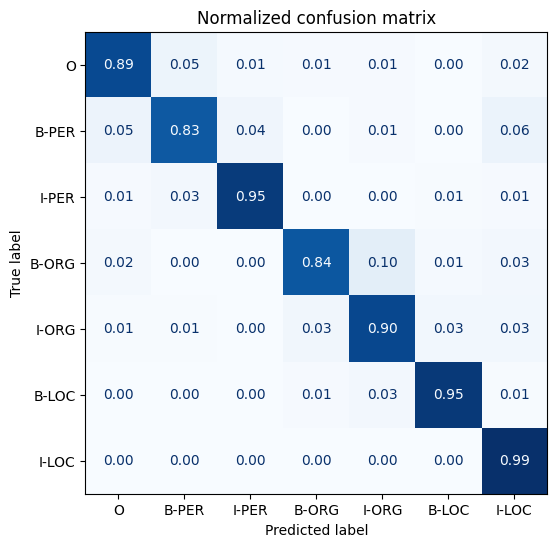

In [49]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt


def plot_confusion_matrix(y_preds, y_true, labels):
    cm = confusion_matrix(y_true, y_preds, normalize="true")
    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", values_format=".2f", ax=ax, colorbar=False)
    plt.title("Normalized confusion matrix")
    plt.show()


plot_confusion_matrix(df_tokens["labels"], df_tokens["predicted_label"], tags.names)

In [50]:
def get_samples(df):
    for _, row in df.iterrows():
        labels, preds, tokens, losses = [], [], [], []
        for i, mask in enumerate(row["attention_mask"]):
            if i not in {0, len(row["attention_mask"])}:
                labels.append(row["labels"][i])
                preds.append(row["predicted_label"][i])
                tokens.append(row["input_tokens"][i])
                losses.append(f"{row['loss'][i]:.2f}")
        df_tmp = pd.DataFrame(
            {"tokens": tokens, "labels": labels, "preds": preds, "losses": losses}
        ).T
        yield df_tmp


df["total_loss"] = df["loss"].apply(sum)
df_temp = df.sort_values(by="total_loss", ascending=False).head(3)

for sample in get_samples(df_temp):
    display(sample)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
tokens,▁',▁'',▁Τ,Κ,▁'',▁',▁',▁'',▁T,▁'',▁',ri,▁'',▁',k,▁'',▁',ala,</s>
labels,O,O,O,IGN,O,O,B-LOC,I-LOC,I-LOC,I-LOC,I-LOC,IGN,I-LOC,I-LOC,IGN,I-LOC,I-LOC,IGN,IGN
preds,O,O,B-ORG,I-ORG,O,O,O,O,B-ORG,O,O,B-ORG,O,O,O,O,O,O,O
losses,0.00,0.00,2.76,0.00,0.00,0.00,10.99,10.39,8.48,5.88,8.59,0.00,7.38,9.11,0.00,8.13,8.44,0.00,0.00


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
tokens,▁'',8,.,▁Juli,▁'',▁:,▁Protest,camp,▁auf,▁dem,▁Gelände,▁der,▁Republika,n,ischen,▁Gar,de,</s>
labels,B-ORG,IGN,IGN,I-ORG,I-ORG,I-ORG,I-ORG,IGN,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,IGN,IGN,I-ORG,IGN,IGN
preds,O,O,O,O,O,O,O,O,O,O,O,O,B-ORG,I-ORG,I-ORG,I-ORG,I-ORG,O
losses,9.54,0.00,0.00,8.35,8.75,9.00,6.33,0.00,6.89,8.80,7.37,6.33,6.18,0.00,0.00,0.01,0.00,0.00


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
tokens,▁United,▁Nations,▁Multi,dimensional,▁Integra,ted,▁Stabil,ization,▁Mission,▁in,▁the,▁Central,▁African,▁Republic,</s>
labels,B-PER,I-PER,I-PER,IGN,I-PER,IGN,I-PER,IGN,I-PER,I-PER,I-PER,I-PER,I-PER,I-PER,IGN
preds,B-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG
losses,6.29,6.21,6.16,0.00,6.02,0.00,5.83,0.00,5.70,5.70,5.52,5.63,5.77,5.47,0.00


In [51]:
df_tmp = df.loc[df["input_tokens"].apply(lambda x: "\u2581(" in x)].head(2)
for sample in get_samples(df_temp):
    display(sample)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
tokens,▁',▁'',▁Τ,Κ,▁'',▁',▁',▁'',▁T,▁'',▁',ri,▁'',▁',k,▁'',▁',ala,</s>
labels,O,O,O,IGN,O,O,B-LOC,I-LOC,I-LOC,I-LOC,I-LOC,IGN,I-LOC,I-LOC,IGN,I-LOC,I-LOC,IGN,IGN
preds,O,O,B-ORG,I-ORG,O,O,O,O,B-ORG,O,O,B-ORG,O,O,O,O,O,O,O
losses,0.00,0.00,2.76,0.00,0.00,0.00,10.99,10.39,8.48,5.88,8.59,0.00,7.38,9.11,0.00,8.13,8.44,0.00,0.00


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
tokens,▁'',8,.,▁Juli,▁'',▁:,▁Protest,camp,▁auf,▁dem,▁Gelände,▁der,▁Republika,n,ischen,▁Gar,de,</s>
labels,B-ORG,IGN,IGN,I-ORG,I-ORG,I-ORG,I-ORG,IGN,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,IGN,IGN,I-ORG,IGN,IGN
preds,O,O,O,O,O,O,O,O,O,O,O,O,B-ORG,I-ORG,I-ORG,I-ORG,I-ORG,O
losses,9.54,0.00,0.00,8.35,8.75,9.00,6.33,0.00,6.89,8.80,7.37,6.33,6.18,0.00,0.00,0.01,0.00,0.00


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
tokens,▁United,▁Nations,▁Multi,dimensional,▁Integra,ted,▁Stabil,ization,▁Mission,▁in,▁the,▁Central,▁African,▁Republic,</s>
labels,B-PER,I-PER,I-PER,IGN,I-PER,IGN,I-PER,IGN,I-PER,I-PER,I-PER,I-PER,I-PER,I-PER,IGN
preds,B-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG
losses,6.29,6.21,6.16,0.00,6.02,0.00,5.83,0.00,5.70,5.70,5.52,5.63,5.77,5.47,0.00


#### Cross-Lingual Transfer 

In [52]:
def get_f1_score(trainer, dataset):
    return trainer.predict(dataset).metrics["test_f1"]


f1_scores = defaultdict(dict)
f1_scores["de"]["de"] = get_f1_score(trainer, panx_de_encoded["test"])
print(f"F1-score of [de] model on [de] dataset: {f1_scores['de']['de']:.3f}")

F1-score of [de] model on [de] dataset: 0.866


In [53]:
text_fr = "jeff Dean est information chez Google en californie"
tag_text(text_fr, tags, trainer.model, xlmr_tokenizer)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
Tokens,<s>,▁je,ff,▁De,an,▁est,▁information,▁chez,▁Google,▁en,▁cali,for,nie,</s>
Tags,O,B-PER,B-PER,I-PER,I-PER,O,O,O,B-ORG,O,B-LOC,I-LOC,I-LOC,O


In [54]:
def evaluate_lang_performance(lang, trainer):
    panx_ds = encode_panx_dataset(panx_ch[lang])
    return get_f1_score(trainer, panx_ds["test"])

In [55]:
f1_scores["de"]["fr"] = evaluate_lang_performance("fr", trainer)
print(f"F1-score of [de] model on [fr] dataset: {f1_scores['de']['fr']:.3f}")

Map:   0%|          | 0/5980 [00:00<?, ? examples/s]

Map:   0%|          | 0/2990 [00:00<?, ? examples/s]

Map:   0%|          | 0/2990 [00:00<?, ? examples/s]

F1-score of [de] model on [fr] dataset: 0.697


In [56]:

f1_scores["de"]["it"] = evaluate_lang_performance("it", trainer)
print(f"F1-score of [de] model on [it] dataset: {f1_scores['de']['it']:.3f}")

Map:   0%|          | 0/1680 [00:00<?, ? examples/s]

Map:   0%|          | 0/840 [00:00<?, ? examples/s]

Map:   0%|          | 0/840 [00:00<?, ? examples/s]

F1-score of [de] model on [it] dataset: 0.675


In [57]:
# hide_input
print(f"F1-score of [de] model on [it] dataset: {f1_scores['de']['it']:.3f}")

F1-score of [de] model on [it] dataset: 0.675


In [58]:

f1_scores["de"]["en"] = evaluate_lang_performance("en", trainer)
print(f"F1-score of [de] model on [en] dataset: {f1_scores['de']['en']:.3f}")

Map:   0%|          | 0/1180 [00:00<?, ? examples/s]

Map:   0%|          | 0/590 [00:00<?, ? examples/s]

Map:   0%|          | 0/590 [00:00<?, ? examples/s]

F1-score of [de] model on [en] dataset: 0.585


### When Does Zero-shot Transfer Make Sense?


In [59]:
def train_on_subset(dataset,num_samples):
    train_ds = dataset["train"].shuffle(seed=42).select(range(num_samples))
    valid_ds = dataset["validation"]
    test_ds = dataset["test"]
    training_args.logging_steps = len(train_ds)//batch_size
    trainer = Trainer(model_init=model_init,args = training_args,
                      data_collator = data_collator,compute_metrics = compute_metrics,
                      train_dataset = train_ds,eval_dataset=valid_ds,tokenizer= xlmr_tokenizer)
    trainer.train()
    if training_args.push_to_hub:
        trainer.push_to_hub(commit_message="Training completed...")
    f1_score= get_f1_score(trainer,test_ds)
    return pd.DataFrame.from_dict(
        {"num_samples":[len(train_ds)],"f1_score":[f1_scores]}
    )


In [60]:
panx_fr_encoded = encode_panx_dataset(panx_ch["fr"])

Map:   0%|          | 0/5980 [00:00<?, ? examples/s]

In [61]:
training_args.push_to_hub=False
metrics_df = train_on_subset(panx_fr_encoded,250)
metrics_df

Epoch,Training Loss,Validation Loss,F1
1,1.659600,1.267376,0.088711
2,1.136500,0.926897,0.392415
3,0.860900,0.784610,0.533236


,num_samples,f1_score
0,250,"{'de': {'de': 0.8663438801936718, 'fr': 0.6970..."


In [62]:

for num_samples in [500, 1000, 2000, 4000]:
    metrics_df= metrics_df.append(train_on_subset(panx_fr_encoded, num_samples),ignore_index=True)

AttributeError: 'DataFrame' object has no attribute 'append'

TypeError: no numeric data to plot

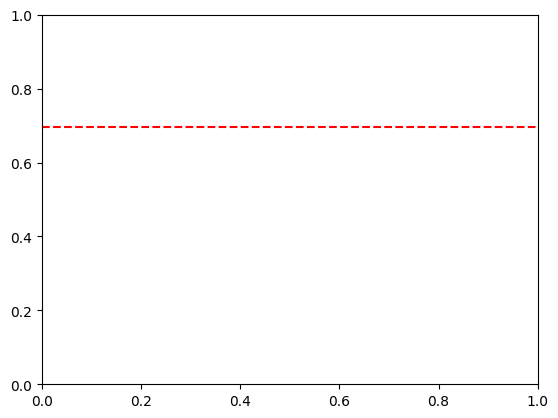

In [63]:
fig,ax = plt.subplots()
ax.axhline(f1_scores["de"]["fr"],ls="--",color="r")
metrics_df.set_index("num_samples").plot(ax=ax)
plt.legend(["zero-shot from de","fine-tuned on fr"],loc="lower right")
plt.ylim((0,1))
plt.xlabel("number of training samples")
plt.ylabel("f1 Score")
plt.show()

### Fine Tuning on Multiple Languages at Once 

In [65]:
from datasets import concatenate_datasets

def concatenate_splits(corpora):
    multi_corpus = DatasetDict()
    for split in corpora[0].keys():
        multi_corpus[split] = concatenate_datasets(
            [corpus[split] for corpus in corpora]
        ).shuffle(seed=42)
    return multi_corpus
panx_de_fr_encoded = concatenate_splits([panx_de_encoded,panx_fr_encoded])


In [66]:
training_args.logging_steps = len(panx_de_fr_encoded["train"])//batch_size
training_args.push_to_hub= True
training_args.output_dir = "xlm-roberta-base-finetuned-panx-de-fr"

trainer = Trainer(model_init=model_init,args= training_args,
                  data_collator =data_collator,compute_metrics = compute_metrics,
                  tokenizer=xlmr_tokenizer,train_dataset = panx_de_fr_encoded["train"],
                  eval_dataset = panx_de_fr_encoded["validation"])

trainer.train()
trainer.push_to_hub(commit_message="Training completed")

Epoch,Training Loss,Validation Loss,F1
1,0.285200,0.196459,0.818464
2,0.149200,0.165306,0.847549
3,0.096600,0.168069,0.863421


Uploading...:   0%|          | 0.00/1.13G [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/swamimanish/xlm-roberta-base-finetuned-panx-de-fr/commit/eb04e3fdd962bfbafc2c79e852c4b10365e1d8f2', commit_message='Training completed', commit_description='', oid='eb04e3fdd962bfbafc2c79e852c4b10365e1d8f2', pr_url=None, repo_url=RepoUrl('https://huggingface.co/swamimanish/xlm-roberta-base-finetuned-panx-de-fr', endpoint='https://huggingface.co', repo_type='model', repo_id='swamimanish/xlm-roberta-base-finetuned-panx-de-fr'), pr_revision=None, pr_num=None)

In [67]:
for lang in langs:
    f1 = evaluate_lang_performance(lang,trainer)
    print(f"F1-score of [de-fr] model on[{lang}] dataset:{f1:.3f}")

Map:   0%|          | 0/12580 [00:00<?, ? examples/s]

Map:   0%|          | 0/6290 [00:00<?, ? examples/s]

Map:   0%|          | 0/6290 [00:00<?, ? examples/s]

F1-score of [de-fr] model on[de] dataset:0.865


F1-score of [de-fr] model on[fr] dataset:0.864


F1-score of [de-fr] model on[it] dataset:0.798


F1-score of [de-fr] model on[en] dataset:0.682


In [69]:
corpora = [panx_de_encoded]

for lang in langs[1:]:
    training_args.output_dir = f"xlm-roberta-base-finetuned-panx-{lang}"
    
    ds_encoded= encode_panx_dataset(panx_ch[lang])
    metrics = train_on_subset(ds_encoded,ds_encoded["train"].num_rows)
    f1_scores[lang][lang]=metrics["f1-scores"][0]
    
    corpora.append(ds_encoded)

Epoch,Training Loss,Validation Loss,F1
1,0.497500,0.305624,0.805815
2,0.238100,0.263588,0.838078
3,0.162400,0.260747,0.845006


No files have been modified since last commit. Skipping to prevent empty commit.


Uploading...:   0%|          | 0.00/1.13G [00:00<?, ?B/s]

No files have been modified since last commit. Skipping to prevent empty commit.


KeyError: 'f1-scores'

In [70]:
corpora_encoded = concatenate_splits(corpora)

In [71]:
training_args.logging_steps = len(corpora_encoded["train"])//batch_size
training_args.output_dir="xlm-roberta-base-finetuned-panx-all"

trainer = Trainer(model_init = model_init,args = training_args,
                data_collator=data_collator,compute_metrics = compute_metrics,
                tokenizer = xlmr_tokenizer, train_dataset=corpora_encoded["train"],
                eval_dataset = corpora_encoded["validation"])

trainer.train()
trainer.push_to_hub(commit_message = "training completed!")


Epoch,Training Loss,Validation Loss,F1
1,0.272300,0.154577,0.815367
2,0.128600,0.136809,0.846219


OSError: [Errno 28] No space left on device: 'xlm-roberta-base-finetuned-panx-all/checkpoint-1575/model.safetensors' -> 'xlm-roberta-base-finetuned-panx-all/model.safetensors'

In [ ]:
for idx , lang in enumerate(langs):
    f1_scores["all"][lang]= get_f1_score(trainer,corpora[idx]['test'])
scores_data = {"de":f1_scores["de"],
               "each":{lang:f1_scores[lang][lang] for lang in langs},
               "all":f1_scores["all"]}
f1_scores_df = pd.DataFrame(scores_data).T.round(4)
f1_scores_df.rename_axis(index="fine-tune on",columns="evaluated on",
                         inplace = True)
f1_scores_df

NameError: name 'langs' is not defined